In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import micropip
await micropip.install("ipywidgets")
from ipywidgets import interactive, widgets, interact
import pandas as pd
import matplotlib.patches as patches
from scipy.stats import norm
%matplotlib inline

<a id="anwendung"></a>
# Anwendung
---

Einer der Hauptanwendungsgebiete der Taylorfunktion oder Taylorreihe ist die Approximation von Funktionen, dessen Funktionswerte nicht direkt berechnet werden können. Hierzu gehören zum Beispiel die trigonometrischen Funktionenen oder die e-Funktion. Taschenrechner verlassen sich für die Werte entweder auf vorprogrammierte Tabellen oder benutzen eine jeweilige Taylorreihe.<br><br>
Ein anderes Feld das von Taylorreihen profotiert ist die Berechnung von Grenzwerten. Hierbei wird es immer spannend wenn man den Grenzwerte um den Wert $0$ finden soll, die Funktion jedoch nicht für $0$ definiert ist.<br><br>
Beispiele dafür wären gebrochen rationale Funktionen. Hier zwei Besipiele:<br><br>
- $\lim_{x \to 0}\frac{\sin(x)}{x} \quad= \lim_{x \to 0}\frac{\overbrace{x-\frac{x^{3}}{3!}+\frac{x^{5}}{5!}-\cdots}^{\text{Taylorreihe von sin(x)}}}{x}$ <br><br>
   $\qquad \qquad  \qquad = \lim_{x \to 0}1-\frac{x^{2}}{3!}+\frac{x^{4}}{5!}-\cdots $<br><br>
   $\qquad \qquad \qquad = 1$ <br>
- $\lim_{x \to 0}\frac{\ln(x^{6}+1)}{5x^{6}} =  \lim_{x \to 0}\frac{\overbrace{x^{6}-\frac{x^{12}}{2}+\frac{x^{18}}{3}-\cdots}^{\text{Taylorreihe von ln(x⁶+1)}}}{5x^{6}} $<br><br>
  $\qquad \qquad  \qquad=\lim_{x \to 0}\frac{1}{5}-\frac{x^{6}}{10}+\frac{x^{12}}{15}-\cdots $<br><br>
  $\qquad \qquad  \qquad= \frac{1}{5} $
<br><br>

## Pendelbeispiel

Bei nicht elementaren Integralen werden Taylorreihen auch sehr nützlich. Ist ein Integral schwierig per Hand auszurechnen, kann man mithilfe der Taylorreihe eine alternative Form dieser Funkion verwenden. Dabei integriert man dann eine bestimmte Anzahl an Termen der Taylorreihe und verwendet diese anstatt der Funktion.<br><br>
Schaut man sich das mal an einem Besipiel aus der Physik an. Die Periode eines einfachen Pendels beschreibt die Zeit die das Pendel benötigt um einen kompletten Schwung von einer Seite zur anderen Seite zu absolvieren. Für ein Pendel mit der Länge $L$ das einen maximalen Winkel von $\theta_{max}$ erreicht ist die Periode $T$ durch <br><br>
$T=4\sqrt{\frac{L}{g}}\int ^{π/2}_0\frac{1}{\sqrt{1−k^2\sin^2θ}}dθ$
<br><br> 

beschrieben mit $g$ der Fallbeschleunigung der Erde und $k = \sin(\frac{\theta_{max}}{2}).$
<br><br>
<img src="pendel.jpg" width=500 height=500 >
<br><br>
Hier ist ein nicht elementares Integral zu finden. Um dieses Integral per Hand berechnen zu können wird ein Teil des Ausdrucks durch die Taylorreihe der binomische Reihe ersetzt. Diese ist berschrieben durch<br><br>

$\frac{1}{\sqrt{1+x}}=1+\sum_{n=1}^∞\frac{(−1)^n}{n!}\frac{1⋅3⋅5⋯(2n−1)}{2^n}x^n$.
<br><br>

$x$ wird ersetzt durch $-k^2\sin^2(\theta)$. So erhält man<br><br>

$T=4\sqrt{\frac{L}{g}}\int ^{π/2}_0(1+\frac{1}{2}k^2\sin^2θ+\frac{1⋅3}{2!2^2}k^4\sin^4θ+⋯)\,dθ.$
<br><br>
Für die Berechnung der Periode werden die ersten beiden Glieder der Reihe verwendet. <br><br>

$T≈4\sqrt{\frac{L}{g}}\int ^{π/2}_0(1+\frac{1}{2}k^2\sin^2θ)\,dθ=2π\sqrt{\frac{L}{g}}(1+\frac{k^2}{4})$
<br><br>
Damit konnte man das nicht elementare Integral umgehen und die Periode des Pendels für beliebige $L$ berechnen.
<br><br>
In der folgenden Code-Zelle sehen Sie wie Sie dieses Integral mit Python lösen können.

In [14]:
from scipy.integrate import quad

def integrand(x, k):
    return 1 / (np.sqrt(1-np.sin(k/2)**2*np.sin(x)**2))
k = 1
L = 2
g = 9.81
I = 4*np.sqrt(L/g) * quad(integrand, 0, np.pi/2, args=(k))[0]
I

3.0251974064923375

## Normalverteilung

Bei nicht elementaren Integralen werden Taylorreihen auch sehr nützlich. Ist ein Integral schwierig per Hand auszurechnen, kann man mithilfe der Taylorreihe eine alternative Form dieser Funkion verwenden. Dabei integriert man dann eine bestimmte Anzahl an Termen der Taylorreihe und verwendet diese anstatt der Funktion.<br>
Ein Integral das ihnen in der Stochastik häufig begegnet ist $\int ^b_a \dfrac{1}{σ\sqrt{2π}}e^{-\frac{1}{2}(\frac{x−μ}{\sigma})^2}\,dx $. Dieses Integral wird für die Berechnung von Häufigkeiten verwendet, bei Datensätzen die normalverteilt sind. Wie bekannt ist $\mu$ der Erwartungswert und $\sigma^2$ die Varianz.<br>
Dieses Integral ist nicht elementar und damit schwierig per Hand zu berechnen. <br><br>
Um das weiterrechnen zu vereinfachen wird $z = \frac{x-\mu}{\sigma}$ gesetzt. Daraus folgt:<br><br> 
$\int^{(b−μ)/σ}_{(a−μ)/σ} \dfrac{1}{\sqrt{2π}} e^{−z^2/2}\,dz.$ <br> <br>
Nun wird die Taylorreihe berechnet. Dafür wird sich zuerst die Taylorreihe von $e^x$ angeschaut.<br>
Die Taylorreihe für $e^x$ ist definiert durch $1+x+\frac{x^2}{2!}+\frac{x^3}{3!}+\frac{x^4}{4!}\cdots$<br>
$x$ mit $-\frac{x^2}{2}$ ersetzen:<br><br>
$e^{{-x^2}/2} = 1+(-\frac{x^2}{2})+\frac{(-\frac{x^2}{2})^2}{2!}+\frac{(-\frac{x^2}{2})^3}{3!}+\frac{(-\frac{x^2}{2})^4}{4!}\cdots$<br><br>
Vereinfacht man den Ausdruck folgt:<br><br>
$e^{{-x^2}/2} = 1-\frac{x^2}{2}+\frac{x^4}{8}-\frac{x^6}{48}+\frac{x^8}{384}\cdots$<br><br>
Daraus folgt die Taylorreihe:<br><br>
$e^{−x^2/2}=\sum_{n=0}^∞(−1)^n\dfrac{x^{2n}}{2^n⋅n!}$<br><br>
Mit der Taylorreihe kann man nun einen Teil des Integrals ersetzen und ihn nun schrittweise integrieren. <br><br>

$\frac{1}{\sqrt{2π}}\int e^{−z^2/2}\,dz=\frac{1}{\sqrt{2π}}\int (1−\frac{z^2}{2^1⋅1!}+\frac{z^4}{2^2⋅2!}−\frac{z^6}{2^3⋅3!}+⋯+(−1)^n\frac{z^{2n}}{2^n⋅n!}+⋯)dz$<br><br>
$=\frac{1}{\sqrt{2π}}(C+z−\frac{z^3}{3⋅2^1⋅1!}+\frac{z^5}{5⋅2^2⋅2!}−\frac{z^7}{7⋅2^3⋅3!}+⋯+(−1)^n\frac{z^{2n+1}}{(2n+1)2^n⋅n!}+⋯)$ 
<br> <br>

Als Beispiel wird angenommen man hätte einen Datensatz mit $\mu = 100$ und $\sigma = 50$. Und man möchte die Häufigkeit zwischen den Datenpunkten $100$ und $200$ berechnen. 


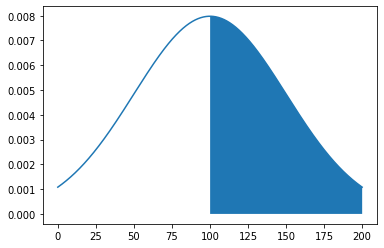

In [4]:
mu = 100 # Erwartungswert
std = 50 # Standardabweichung
snd = norm(mu, std) # Normalverteilung erstellen
x = np.linspace(0, 200, 1000) # Liste im Bereich 0 bis 200 erstellen
ax = plt.plot(x, snd.pdf(x)) # Normalverteilung plotten
x_fill = x[500:1000] # x-Werte zum markieren auswählen
y_fill = snd.pdf(x)[500:1000] # y-Werte zum markieren auswählen
poly = plt.fill_between(x_fill,y_fill) # ausgewählten Bereich ausmalen


Nun wird die Häufigkeit mithilfe des Integrals berechnet. Dafür in das Integral einsetzen: <br><br>

$\frac{1}{\sqrt{2\pi}}\int^{(200−μ)/σ}_{(100−μ)/σ} e^{−z^2/2}\,dz $ <br><br>
$= \frac{1}{\sqrt{2\pi}}\int^{2}_{0} e^{−z^2/2}\,dz$ <br><br>
Für die Berechnung werden nur die ersten $5$ Elemente der Reihe verwendet.<br><br>
$=\frac{1}{\sqrt{2π}}(2−\frac{8}{6}+\frac{32}{40}−\frac{128}{336}+\frac{512}{3456}+⋯)$
$=0,4922398931$<br><br>

Damit liegt die Wahrscheinlichkeit bei ungefähr $49,22 \%$. In der unteren Codezell wird dies mithilfe von Python berechnet. Dort kommt man auf ungefähr $47,72\%$ damit existiert eine Differenz von knapp einem Prozent. Wenn man mehr Elemente der Reihe verwenden würde, würde die Genauigkeit steigen.

In [5]:
mu = 100 # Erwartungswert
std = 50 # Standardabweichung
snd = norm(mu, std) # Normalverteilung erstellen

cdf_upper_limit = snd.cdf(200) # Häufigkeit der Normalverteilung bis 200 berechnen
cdf_lower_limit = snd.cdf(100) # Häufigkeit der Normalverteilung bis 100 berechnen
 
prob = cdf_upper_limit - cdf_lower_limit # Häufigkeiten voneinander abziehen

print("Wahrscheinlichkeit:",round(prob,4)*100,"%") 

Wahrscheinlichkeit: 47.72 %
